In [6]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter

# Download latest version
path = kagglehub.dataset_download("denkuznetz/taxi-price-prediction")

print("Path to dataset files:", path)


df = pd.read_csv(path+'\\taxi_trip_pricing.csv')
df

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\denkuznetz\taxi-price-prediction\versions\1


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [11]:
df3 = df

#df3 = df3.dropna()

df3['Afternoon'] = df3['Time_of_Day'].map({'Afternoon': 1}).fillna(0)
df3['Morning'] = df3['Time_of_Day'].map({'Morning': 1}).fillna(0)
df3['Evening'] = df3['Time_of_Day'].map({'Evening': 1}).fillna(0)
df3['Night'] = df3['Time_of_Day'].map({'Night': 1}).fillna(0)
df3 = df3.drop(['Time_of_Day'], axis = 1)

df3['Day_of_Week'] = df3['Day_of_Week'].map({'Weekday': 1}).fillna(0)

df3['Traffic_Medium'] = df3['Traffic_Conditions'].map({'Medium': 1}).fillna(0)
df3['Traffic_Low'] = df3['Traffic_Conditions'].map({'Low': 1}).fillna(0)
df3['Traffic_High'] = df3['Traffic_Conditions'].map({'High': 1}).fillna(0)
df3 = df3.drop(['Traffic_Conditions'], axis = 1)

df3['Weather_Clear'] = df3['Weather'].map({'Clear': 1}).fillna(0)
df3['Weather_Rain'] = df3['Weather'].map({'Rain': 1}).fillna(0)
df3['Weather_Snow'] = df3['Weather'].map({'Snow': 1}).fillna(0)
df3 = df3.drop(['Weather'], axis = 1)

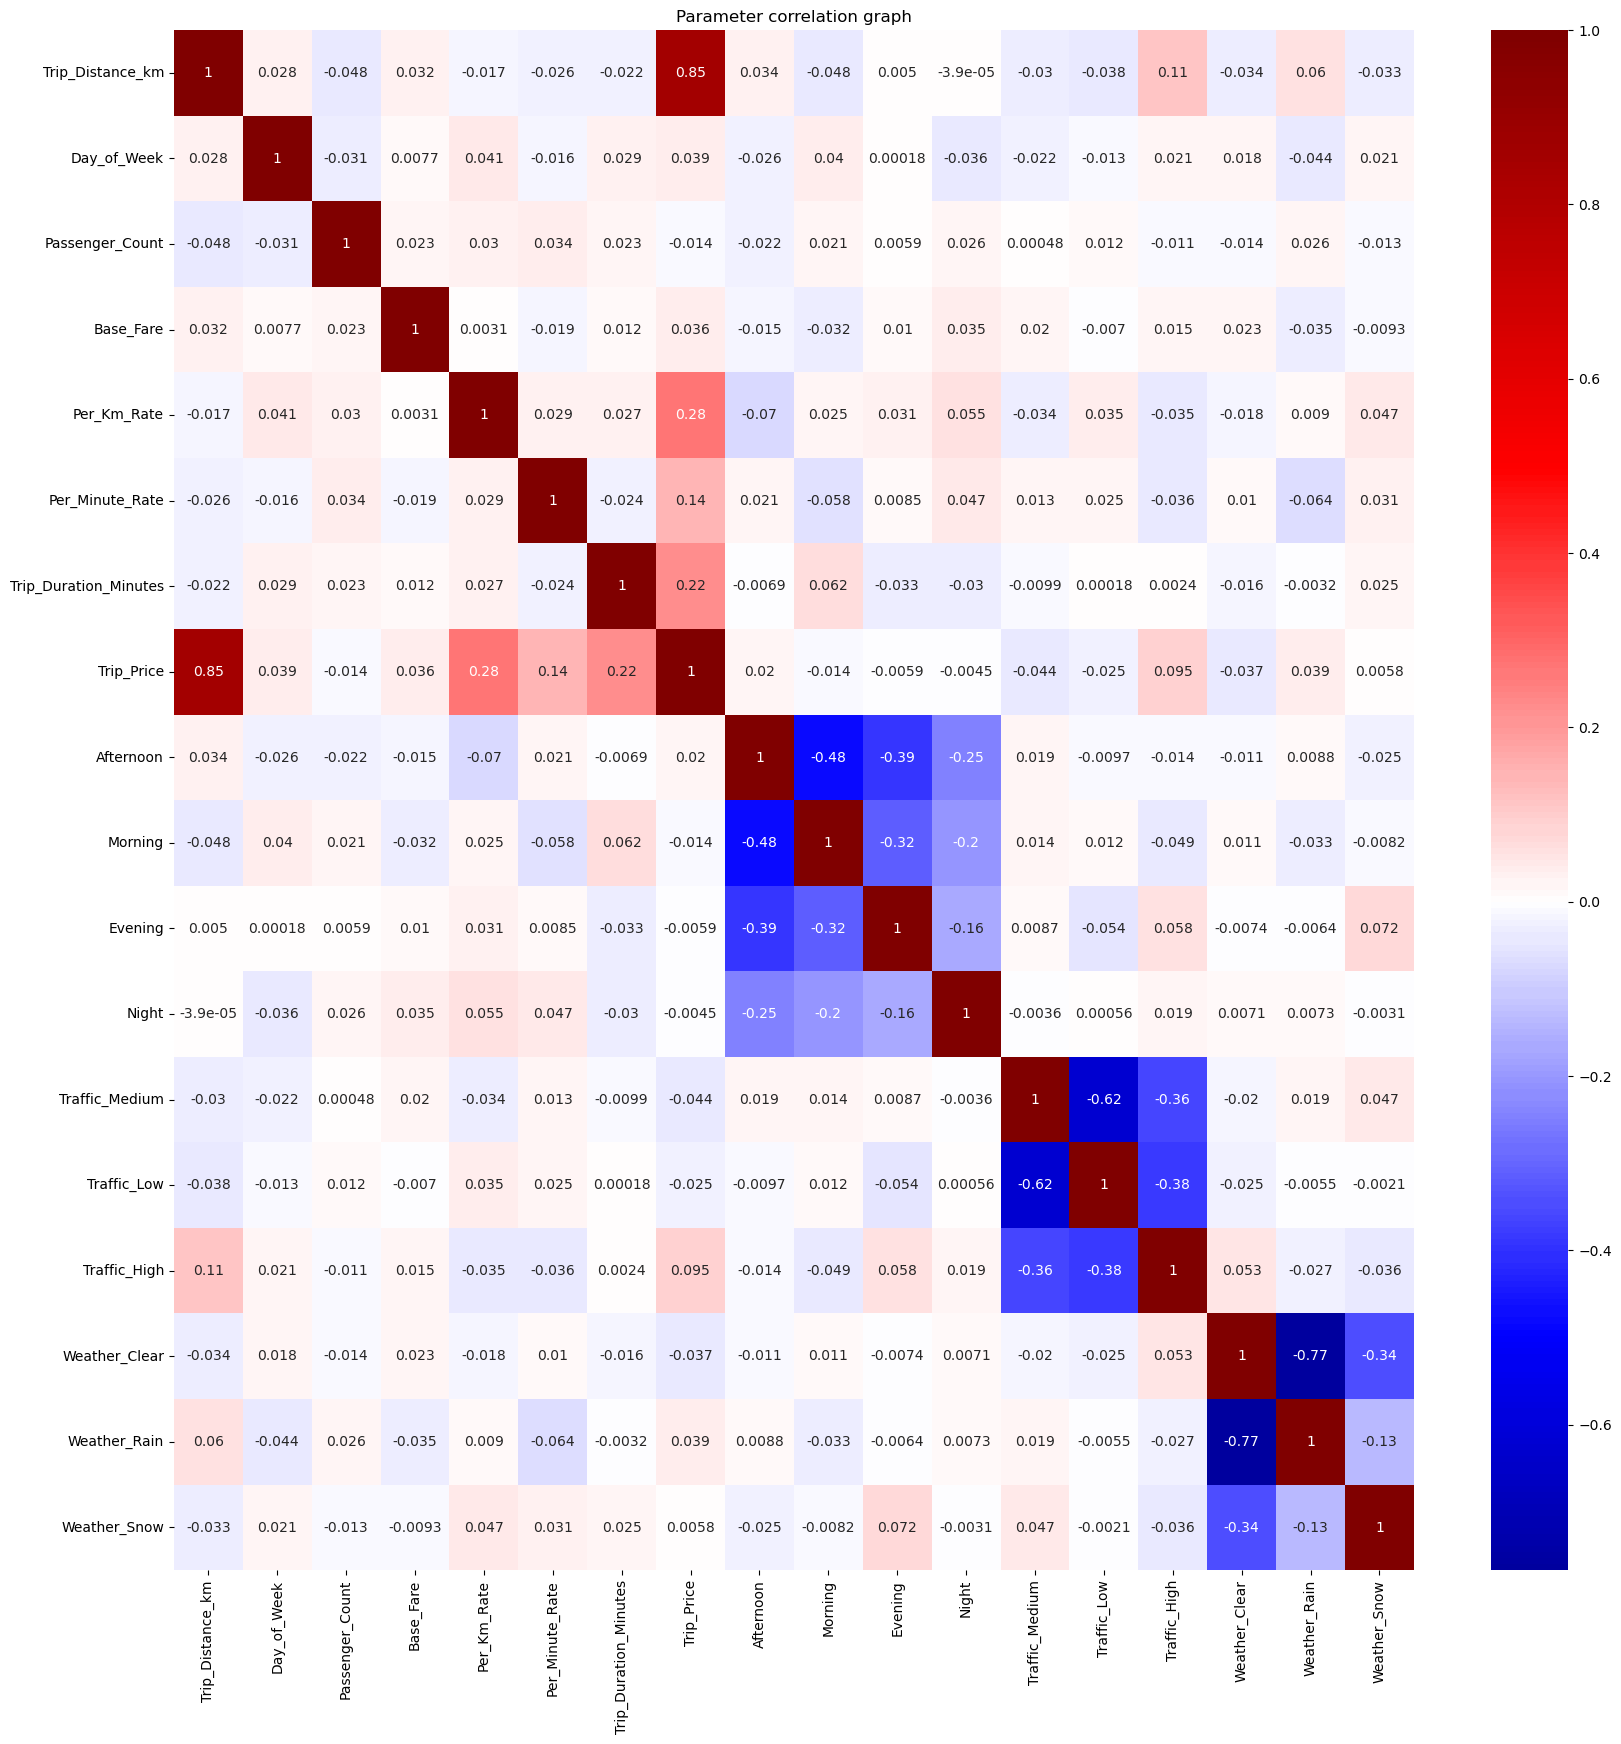

In [17]:
plt.figure(figsize=(20, 20))
seaborn.heatmap(df3.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [18]:
# для заполнения пропущенных значений в ячейках на основе данных из наиболее похожих строк

from sklearn.impute import KNNImputer

indx_price = df3.columns.get_loc('Trip_Price')

arr_temp = df3.to_numpy()

imputer = KNNImputer(n_neighbors = 10)

arr_temp = imputer.fit_transform(arr_temp)

x = np.delete(arr_temp, indx_price, axis=1)
y = arr_temp[:, indx_price]

In [45]:
from sklearn.model_selection import train_test_split

split_num = 0.1
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=split_num, random_state=42)

In [51]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

reg = LinearRegression().fit(x_train, y_train) 
lasso = Lasso(alpha=0.3).fit(x_train, y_train)
clf = DecisionTreeRegressor(random_state = 42, max_depth = 20, min_samples_leaf = 10).fit(x_train, y_train)
rfr = RandomForestRegressor(max_depth = 20, random_state = 0, min_samples_leaf = 10, n_estimators = 100).fit(x_train, y_train)

In [52]:
reg_score_train = reg.score(x_train, y_train)
reg_score_test = reg.score(x_test, y_test)
lasso_score_train = lasso.score(x_train, y_train)
lasso_score_test = lasso.score(x_test, y_test)
clf_score_train = clf.score(x_train, y_train)
clf_score_test = clf.score(x_test, y_test)
rfr_score_train = rfr.score(x_train, y_train)
rfr_score_test = rfr.score(x_test, y_test)

print('R^2 метрика для линейной регрессии для выборки обучающей / тестовой: ', round(reg_score_train, 3), ' / ', round(reg_score_test, 3))
print('R^2 метрика для лин. регр. c лассо регуляризацией для выборки обучающей / тестовой: ', round(lasso_score_train, 3), ' / ', round(lasso_score_test, 3))
print('R^2 метрика для дерева решений для выборки обучающей / тестовой: ', round(clf_score_train, 3), ' / ', round(clf_score_test, 3))
print('R^2 метрика для случайного леса для выборки обучающей / тестовой: ', round(rfr_score_train, 3), ' / ', round(rfr_score_test, 3))

R^2 метрика для линейной регрессии для выборки обучающей / тестовой:  0.856  /  0.766
R^2 метрика для лин. регр. c лассо регуляризацией для выборки обучающей / тестовой:  0.85  /  0.711
R^2 метрика для дерева решений для выборки обучающей / тестовой:  0.944  /  0.855
R^2 метрика для случайного леса для выборки обучающей / тестовой:  0.946  /  0.919


In [56]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits = int(1/split_num), random_state = 42, shuffle = True)

reg_score_val = list(map(lambda x: round(float(x), 3), cross_val_score(reg, x, y, cv = kf)))
lasso_score_val = list(map(lambda x : round(float(x), 3), cross_val_score(lasso, x, y, cv = kf)))
clf_score_val = list(map(lambda x : round(float(x), 3), cross_val_score(clf, x, y, cv = kf)))
rfr_score_val = list(map(lambda x : round(float(x), 3), cross_val_score(rfr, x, y, cv = kf)))

print('R^2 метрика по k-fold разложениям для линейной регрессии: \t\t', reg_score_val)
print('R^2 метрика по k-fold разложениям для лин. регр. c лассо рег-ей: \t', lasso_score_val)
print('R^2 метрика по k-fold разложениям для дерева решений: \t\t\t', clf_score_val)
print('R^2 метрика по k-fold разложениям для случайного леса: \t\t\t', rfr_score_val)

R^2 метрика по k-fold разложениям для линейной регрессии: 		 [0.766, 0.808, 0.799, 0.911, 0.8, 0.839, 0.855, 0.87, 0.893, 0.779]
R^2 метрика по k-fold разложениям для лин. регр. c лассо рег-ей: 	 [0.711, 0.811, 0.799, 0.912, 0.785, 0.837, 0.855, 0.882, 0.887, 0.778]
R^2 метрика по k-fold разложениям для дерева решений: 			 [0.855, 0.894, 0.93, 0.94, 0.863, 0.92, 0.916, 0.78, 0.903, 0.891]
R^2 метрика по k-fold разложениям для случайного леса: 			 [0.92, 0.951, 0.942, 0.95, 0.901, 0.925, 0.928, 0.841, 0.912, 0.944]


In [57]:
print("для линейной регрессии: \t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(reg_score_val).mean(), np.array(reg_score_val).std()))
print("для лин. регр. c лассо рег-ей: \t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(lasso_score_val).mean(), np.array(lasso_score_val).std()))
print("для дерева решений: \t\t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(clf_score_val).mean(), np.array(clf_score_val).std()))
print("для случайного леса: \t\t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(rfr_score_val).mean(), np.array(rfr_score_val).std()))

для линейной регрессии: 		точность 0.83 со стандартным отклонением 0.05
для лин. регр. c лассо рег-ей: 		точность 0.83 со стандартным отклонением 0.06
для дерева решений: 			точность 0.89 со стандартным отклонением 0.04
для случайного леса: 			точность 0.92 со стандартным отклонением 0.03


In [58]:
# в данном случае, как по R^2 метрике обученной модели, так и по устойчивости при кросс-валидации, лучшие показатели имеет RandomForest

In [63]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(x_train.shape[1], activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dense(x_train.shape[1], activation ='relu'),
    keras.layers.Dense(1, activation='relu') 
])

#model.summary()

model.compile(  optimizer = 'adam',
                loss = 'mse',
                metrics = ['R2Score'],
                )

early_stopping = EarlyStopping(
                    monitor='R2Score',
                    patience = 50,
                    verbose = 0,
                    restore_best_weights = True, #смотрим относительно лучшего результата, а не последнего
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle=True
        )

train_loss, train_r2 = model.evaluate(x_train, y_train)
test_loss, test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', train_r2, ' \ ', test_r2)

D:\zmei\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - R2Score: 0.9683 - loss: 53.0103 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9472 - loss: 30.3931 

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.9682556390762329  \  0.9472362995147705


In [195]:
num = int(1/split_num)
split_x = []
split_y = []

start = 0
for i in range(num):
    step = int(len(x) / 10)
    split_x.append(x[start:(start + step)])
    split_y.append(y[start:(start + step)])
    start+=step

cros_val_matr_x = []
cros_val_matr_y = []

for i in range(num):
    temp_x = []
    temp_y = []
    for j in range(num):
        if j != i:
            temp_x.append(split_x[j])
            temp_y.append(split_y[j])
    temp_x.append(split_x[i]) # последний массив - тестовый
    temp_y.append(split_y[i])
    cros_val_matr_x.append(temp_x)
    cros_val_matr_y.append(temp_y)

arr_score = []

for i in range(num):
    temp_x_train = np.vstack(cros_val_matr_x[i][0:num-2])
    temp_y_train = np.vstack(cros_val_matr_y[i][0:num-2]).flatten()
    temp_x_test = cros_val_matr_x[i][num-1]
    temp_y_test = cros_val_matr_y[i][num-1]
    model.fit(
        x = temp_x_train,
        y = temp_y_train,
        batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle=True
        )
    test_loss, test_r2 = model.evaluate(temp_x_test, temp_y_test)
    arr_score.append(test_r2)
        

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9244 - loss: 151.2945 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9792 - loss: 43.1289 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9814 - loss: 51.7266 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9889 - loss: 19.1708 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9766 - loss: 36.7785 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - R2Score: 0.9706 - loss: 42.6165 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - R2Score: 0.9658 - loss: 43.5315 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9613 - loss: 57.1912 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.9528 - loss: 38.2423 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - R2Score: 0.8933 - loss: 36.1711 


In [201]:
temp_a_score = arr_score
temp_a_score = list(map(lambda x: round(float(x), 3), temp_a_score))

print('R^2 метрика по k-fold разложениям для нейронной сети:\t', temp_a_score)
print("для нейронной сети: \t\t\t\t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(temp_a_score).mean(), np.array(temp_a_score).std()))

R^2 метрика по k-fold разложениям для нейронной сети:	 [0.924, 0.979, 0.981, 0.989, 0.977, 0.971, 0.966, 0.961, 0.953, 0.893]
для нейронной сети: 					точность 0.96 со стандартным отклонением 0.03


In [203]:
# таким образом, как по R^2 метрике обученной сети, так и по устойчивости при кросс-валидации, нейронна сеть имеет более высокие показатели, чем RandomForest
# следовательно, полносвязкная нейронная сеть для данной задачи подходит лучше всего